# Image Captioning — EfficientNet-B0 Encoder

Drop-in alternative to the ResNet-50 encoder in `EncoderResnet/`. Same
256-d output embedding, same vocab, same image normalization, same export
schema — so the LSTM decoder in `DecoderLSTM/` accepts this encoder without
any code changes.

**What's different vs. ResNet-50:**
- Backbone: `efficientnet_b0` (ImageNet-1k v1 weights, 1280-d features)
- Fine-tune scope: last two MBConv blocks (`features[-2:]`), analogous to ResNet's `layer4`
- ~5M backbone params vs. ResNet50's ~25M

Everything else (projection head shape, decoder used during joint training,
loss, optimizer, scheduler, augmentation, eval) is kept identical so the
ResNet-vs-EfficientNet comparison is fair.

## 1. Install & Imports

In [35]:
# ─── Install evaluation libraries ────────────────────────────────────────────
# Kaggle ships nltk + rouge-score in its base image; the pip line is a no-op
# when offline. pycocoevalcap is NOT used (CIDEr is implemented inline below).
import sys, subprocess, contextlib, io

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    try:
        subprocess.run(
            [sys.executable, '-m', 'pip', '-q', 'install', 'nltk', 'rouge-score'],
            check=False, timeout=60,
        )
    except Exception:
        pass  # offline is fine — both libs are pre-installed on Kaggle

import nltk


In [36]:
import os, json, pickle, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from torchvision import models, transforms
from torchvision.models import EfficientNet_B0_Weights


## 2. Config & Device (Multi-GPU)

In [37]:
# ─── Paths (matches the joox1113/interior-room-images-captions-houzz dataset) ─
# Metadata (vocab.pkl + split_*.csv) lives deep under "for data kaggle/..."
# Images live at top-level images/images/<room>/<file>.jpg (double 'images'!)
PREP        = Path('/kaggle/input/datasets/joox1113/interior-room-images-captions-houzz/for data kaggle/for data kaggle/stage3_preprocessing/preprocessing_outputs')
IMAGES_BASE = Path('/kaggle/input/datasets/joox1113/interior-room-images-captions-houzz/images/images')
SAVE_PATH   = Path('/kaggle/working/')
SAVE_PATH.mkdir(exist_ok=True)

# Quick sanity-check: these should all print True before training
assert (PREP / 'vocab.pkl').exists(),       f'vocab.pkl missing under {PREP}'
assert (PREP / 'split_train.csv').exists(), f'split_train.csv missing under {PREP}'
assert (IMAGES_BASE / 'bathroom').exists(), f'bathroom/ missing under {IMAGES_BASE}'
print('paths OK')

# ─── Multi-GPU setup ─────────────────────────────────────────────────────────
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPUS    = torch.cuda.device_count()
USE_MULTI = N_GPUS > 1

print(f'Device      : {DEVICE}')
print(f'GPUs found  : {N_GPUS}')
print(f'Multi-GPU   : {USE_MULTI}')
if USE_MULTI:
    for i in range(N_GPUS):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

# ─── Hyperparameters (kept identical to ResNet run for a fair comparison) ────
EMBED_DIM    = 256
HIDDEN_DIM   = 512
VOCAB_SIZE   = None  # set after loading vocab

BATCH_SIZE   = 32 * max(1, N_GPUS)
LR           = 5e-5
NUM_EPOCHS   = 50
PATIENCE     = 7
MAX_SEQ_LEN  = 40
FINE_TUNE    = True
DROPOUT      = 0.3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.1
GRAD_CLIP    = 1.0

print(f'\nBatch size  : {BATCH_SIZE}')
print(f'Learning rate: {LR}')
print(f'Embed dim   : {EMBED_DIM}')

paths OK
Device      : cuda
GPUs found  : 2
Multi-GPU   : True
  GPU 0: Tesla T4
  GPU 1: Tesla T4

Batch size  : 64
Learning rate: 5e-05
Embed dim   : 256


## 3. Vocabulary & Data

In [38]:
# ─── Load Vocabulary ─────────────────────────────────────────────────────────
with open(PREP / 'vocab.pkl', 'rb') as f:
    vocab = pickle.load(f)

word2idx   = vocab['word2idx']
idx2word   = vocab['idx2word']
VOCAB_SIZE = vocab['vocab_size']
PAD_IDX    = vocab['pad_idx']    # 0
START_IDX  = vocab['start_idx']  # 1
END_IDX    = vocab['end_idx']    # 2

# ImageNet stats — required to match the pretrained backbone
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

# ─── Load DataFrames ─────────────────────────────────────────────────────────
train_df = pd.read_csv(PREP / 'split_train.csv')
val_df   = pd.read_csv(PREP / 'split_val.csv')
test_df  = pd.read_csv(PREP / 'split_test.csv')

for df in (train_df, val_df, test_df):
    df['tokens'] = df['tokens'].apply(eval)

print(f'Vocab size : {VOCAB_SIZE}')
print(f'Train      : {len(train_df):,}')
print(f'Val        : {len(val_df):,}')
print(f'Test       : {len(test_df):,}')


Vocab size : 4207
Train      : 10,984
Val        : 1,373
Test       : 1,374


## 4. Dataset & DataLoader

In [39]:
# ─── Transforms (same as ResNet run) ─────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMG_MEAN, std=IMG_STD),
])


class HouzzDataset(Dataset):
    def __init__(self, df, images_base: Path, transform=None,
                 max_seq_len: int = MAX_SEQ_LEN):
        self.df          = df.reset_index(drop=True)
        self.images_base = images_base
        self.transform   = transform
        self.max_seq_len = max_seq_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_name = '/'.join(row['local_path'].split('/')[1:])   # strip leading 'images/'
        image    = Image.open(IMAGES_BASE / img_name).convert('RGB')
        if self.transform:
            image = self.transform(image)                       # resize + normalize
        caption = torch.tensor(row['tokens'], dtype=torch.long)
        return image, caption                                   # (3,224,224) tensor, (40,) tensor

        tokens  = row['tokens'][:self.max_seq_len - 2]
        caption = torch.tensor([START_IDX] + tokens + [END_IDX], dtype=torch.long)
        return image, caption


def collate_fn(batch):
    images, captions = zip(*batch)
    images   = torch.stack(images, 0)
    captions = pad_sequence(captions, batch_first=True, padding_value=PAD_IDX)
    return images, captions


NUM_WORKERS = min(4 * max(1, N_GPUS), os.cpu_count() or 4)

train_ds = HouzzDataset(train_df, IMAGES_BASE, train_transform)
val_ds   = HouzzDataset(val_df,   IMAGES_BASE, val_transform)
test_ds  = HouzzDataset(test_df,  IMAGES_BASE, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          collate_fn=collate_fn)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')
print(f'Workers       : {NUM_WORKERS}')


Train batches : 172
Val batches   : 22
Test batches  : 22
Workers       : 4


## 5. Model Architecture

**Encoder** — EfficientNet-B0 backbone (frozen except last two MBConv blocks)
with a projection head that mirrors the ResNet variant exactly:

```
Image (3, 224, 224)
  └── EfficientNet-B0 features  → (1280,)        # vs ResNet's 2048
      └── Linear(1280 → 1024) + ReLU + Dropout
          └── Linear(1024 → 256) + LayerNorm     # ← same 256-d as ResNet
```

**Decoder** — a small GRU used only during joint training of the encoder
(matches the ResNet notebook's setup). The exported encoder is what the
real LSTM decoder consumes.

In [40]:
class EncoderEfficientNetB0(nn.Module):
    """EfficientNet-B0 encoder with a 256-d projection head.

    Drop-in replacement for EncoderResNet50: same forward signature, same
    output dimension, so DecoderLSTM works against it without changes.
    """

    def __init__(self, embed_dim: int = EMBED_DIM, fine_tune: bool = FINE_TUNE,
                 dropout: float = DROPOUT):
        super().__init__()

        backbone = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

        # Freeze all backbone params first
        for p in backbone.parameters():
            p.requires_grad = False

        # Unfreeze the last two MBConv blocks — analogous to ResNet's layer4
        if fine_tune:
            for p in backbone.features[-2:].parameters():
                p.requires_grad = True

        # EfficientNet-B0 classifier is Sequential(Dropout, Linear(1280, 1000)).
        # We strip it and pull the 1280-d feature vector instead.
        in_features        = backbone.classifier[1].in_features   # 1280
        backbone.classifier = nn.Identity()
        self.backbone      = backbone

        # Projection head — same shape as ResNet variant, only input dim changes
        self.projection = nn.Sequential(
            nn.Linear(in_features, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(1024, embed_dim),
            nn.LayerNorm(embed_dim),
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features = self.backbone(images)   # (B, 1280)
        return self.projection(features)   # (B, embed_dim)


print('EncoderEfficientNetB0 defined')


EncoderEfficientNetB0 defined


In [41]:
# Temporary GRU decoder — used only to train the encoder end-to-end.
# The production LSTM lives in DecoderLSTM/.
class DecoderGRU(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int = EMBED_DIM,
                 hidden_dim: int = HIDDEN_DIM, num_layers: int = 2,
                 dropout: float = DROPOUT):
        super().__init__()

        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.hidden_proj = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

        self.fc_out = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, vocab_size),
        )
        self.num_layers = num_layers

    def forward(self, features: torch.Tensor,
                captions: torch.Tensor) -> torch.Tensor:
        h0 = self.hidden_proj(features)                       # (B, hidden)
        h0 = h0.unsqueeze(0).repeat(self.num_layers, 1, 1)    # (layers, B, hidden)

        embeds = self.embed(captions[:, :-1])                 # (B, T-1, embed)
        out, _ = self.gru(embeds, h0)                         # (B, T-1, hidden)
        return self.fc_out(out)                               # (B, T-1, vocab)


print('DecoderGRU defined')


DecoderGRU defined


In [42]:
# ─── Build models ────────────────────────────────────────────────────────────
encoder = EncoderEfficientNetB0(embed_dim=EMBED_DIM, fine_tune=FINE_TUNE,
                                dropout=DROPOUT)
decoder = DecoderGRU(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                     hidden_dim=HIDDEN_DIM, num_layers=2, dropout=DROPOUT)

if USE_MULTI:
    encoder = nn.DataParallel(encoder)
    decoder = nn.DataParallel(decoder)
    print(f'Using DataParallel on {N_GPUS} GPUs')

encoder = encoder.to(DEVICE)
decoder = decoder.to(DEVICE)

enc_total     = sum(p.numel() for p in encoder.parameters())
enc_trainable = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
dec_total     = sum(p.numel() for p in decoder.parameters())

print(f'Encoder total params    : {enc_total:,}')
print(f'Encoder trainable params: {enc_trainable:,}')
print(f'Decoder total params    : {dec_total:,}')
print(f'Total trainable         : {enc_trainable + dec_total:,}')


Using DataParallel on 2 GPUs
Encoder total params    : 5,582,204
Encoder trainable params: 2,704,048
Decoder total params    : 6,125,423
Total trainable         : 8,829,471


## 6. Loss, Optimizer & Scheduler

In [43]:
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_IDX,
    label_smoothing=LABEL_SMOOTH,
)

trainable_params = (
    list(filter(lambda p: p.requires_grad, encoder.parameters())) +
    list(decoder.parameters())
)
optimizer = optim.AdamW(trainable_params, lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5,
)

print('Criterion, Optimizer, Scheduler ready')
print(f'  Trainable param groups: {len(trainable_params):,} tensors')


Criterion, Optimizer, Scheduler ready
  Trainable param groups: 35 tensors


## 7. Helpers: Token Accuracy & Smoke Test

In [44]:
def token_accuracy(logits: torch.Tensor, targets: torch.Tensor) -> float:
    preds = logits.argmax(dim=-1)
    mask  = targets != PAD_IDX
    correct = ((preds == targets) & mask).sum().item()
    total   = mask.sum().item()
    return correct / max(total, 1)


# ─── Smoke test ──────────────────────────────────────────────────────────────
encoder.eval(); decoder.eval()
with torch.no_grad():
    imgs, caps = next(iter(train_loader))
    imgs, caps = imgs.to(DEVICE), caps.to(DEVICE)
    feats  = encoder(imgs)
    logits = decoder(feats, caps)
    print(f'Image batch : {imgs.shape}')
    print(f'Caption batch: {caps.shape}')
    print(f'Features    : {feats.shape}   (expect [B, {EMBED_DIM}])')
    print(f'Logits      : {logits.shape} (expect [B, T-1, {VOCAB_SIZE}])')
    assert feats.shape[-1] == EMBED_DIM


Image batch : torch.Size([64, 3, 224, 224])
Caption batch: torch.Size([64, 40])
Features    : torch.Size([64, 256])   (expect [B, 256])
Logits      : torch.Size([64, 39, 4207]) (expect [B, T-1, 4207])


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/linear.py:134: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return F.linear(input, self.weight, self.bias)


## 8. Training Loop

In [45]:
def run_epoch(loader, is_train: bool = True):
    encoder.train(is_train)
    decoder.train(is_train)

    total_loss    = 0.0
    total_correct = 0
    total_tokens  = 0

    ctx  = torch.enable_grad() if is_train else torch.no_grad()
    desc = 'Train' if is_train else 'Val  '

    with ctx:
        pbar = tqdm(loader, desc=desc, leave=False)
        for images, captions in pbar:
            images   = images.to(DEVICE, non_blocking=True)
            captions = captions.to(DEVICE, non_blocking=True)

            features = encoder(images)              # (B, 256)
            logits   = decoder(features, captions)  # (B, T-1, vocab)
            targets  = captions[:, 1:]

            loss = criterion(
                logits.reshape(-1, VOCAB_SIZE),
                targets.reshape(-1),
            )

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(trainable_params, max_norm=GRAD_CLIP)
                optimizer.step()

            preds   = logits.argmax(dim=-1)
            mask    = targets != PAD_IDX
            correct = ((preds == targets) & mask).sum().item()
            tokens  = mask.sum().item()

            total_loss    += loss.item()
            total_correct += correct
            total_tokens  += tokens

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc' : f'{correct/max(tokens,1):.3f}',
            })

    avg_loss = total_loss    / len(loader)
    avg_acc  = total_correct / max(total_tokens, 1)
    return avg_loss, avg_acc


history          = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss    = float('inf')
patience_counter = 0

print('Training started ...\n')
for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    train_loss, train_acc = run_epoch(train_loader, is_train=True)
    val_loss,   val_acc   = run_epoch(val_loader,   is_train=False)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    flag    = ''

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save({
            'epoch'         : epoch + 1,
            'encoder'       : (encoder.module if USE_MULTI else encoder).state_dict(),
            'decoder'       : (decoder.module if USE_MULTI else decoder).state_dict(),
            'optimizer'     : optimizer.state_dict(),
            'best_val_loss' : best_val_loss,
            'vocab'         : vocab,
            'embed_dim'     : EMBED_DIM,
            'backbone'      : 'efficientnet_b0',
        }, SAVE_PATH / 'best_model.pth')
        flag = ' saved'
    else:
        patience_counter += 1

    print(f'Epoch [{epoch+1:>2}/{NUM_EPOCHS}]  '
          f'train loss={train_loss:.4f} acc={train_acc:.4f}  '
          f'val loss={val_loss:.4f} acc={val_acc:.4f}  '
          f'({elapsed:.0f}s){flag}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping — val loss did not improve for {PATIENCE} epochs')
        break

print(f'\nBest val loss: {best_val_loss:.4f}')

with open(SAVE_PATH / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)


Training started ...



Train:   0%|          | 0/172 [00:00<?, ?it/s]

Val  :   0%|          | 0/22 [00:00<?, ?it/s]

Epoch [ 1/50]  train loss=6.6776 acc=0.0623  val loss=5.6883 acc=0.0945  (76s) saved


Train:   0%|          | 0/172 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/22 [00:01<?, ?it/s]

Epoch [49/50]  train loss=3.3737 acc=0.5025  val loss=3.4783 acc=0.4972  (112s)


Train:   0%|          | 0/172 [00:01<?, ?it/s]

Val  :   0%|          | 0/22 [00:01<?, ?it/s]

Epoch [50/50]  train loss=3.3626 acc=0.5038  val loss=3.4725 acc=0.4990  (111s) saved

Best val loss: 3.4725


## 9. Training History Plot

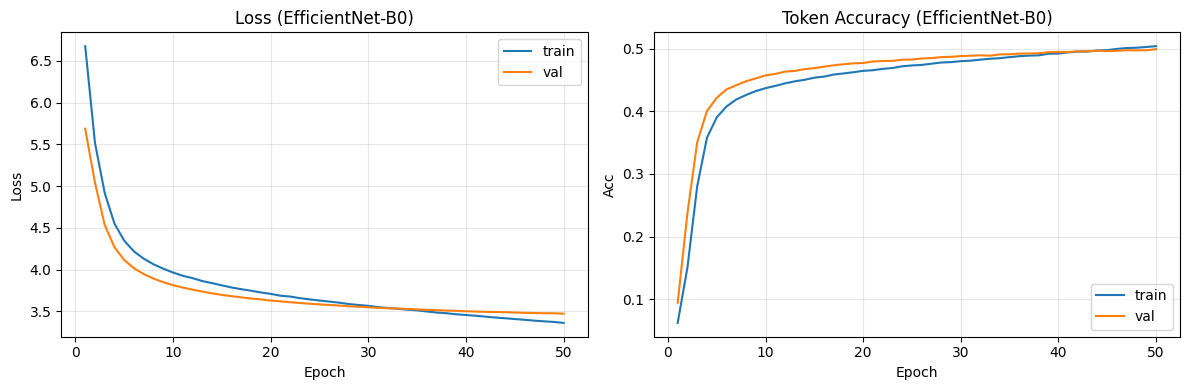

In [46]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_ran, history['train_loss'], label='train')
axes[0].plot(epochs_ran, history['val_loss'],   label='val')
axes[0].set_title('Loss (EfficientNet-B0)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history['train_acc'], label='train')
axes[1].plot(epochs_ran, history['val_acc'],   label='val')
axes[1].set_title('Token Accuracy (EfficientNet-B0)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Acc')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_PATH / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Load Best & Generate Captions (Greedy)

Loaded checkpoint from epoch 50 (val_loss=3.4725)


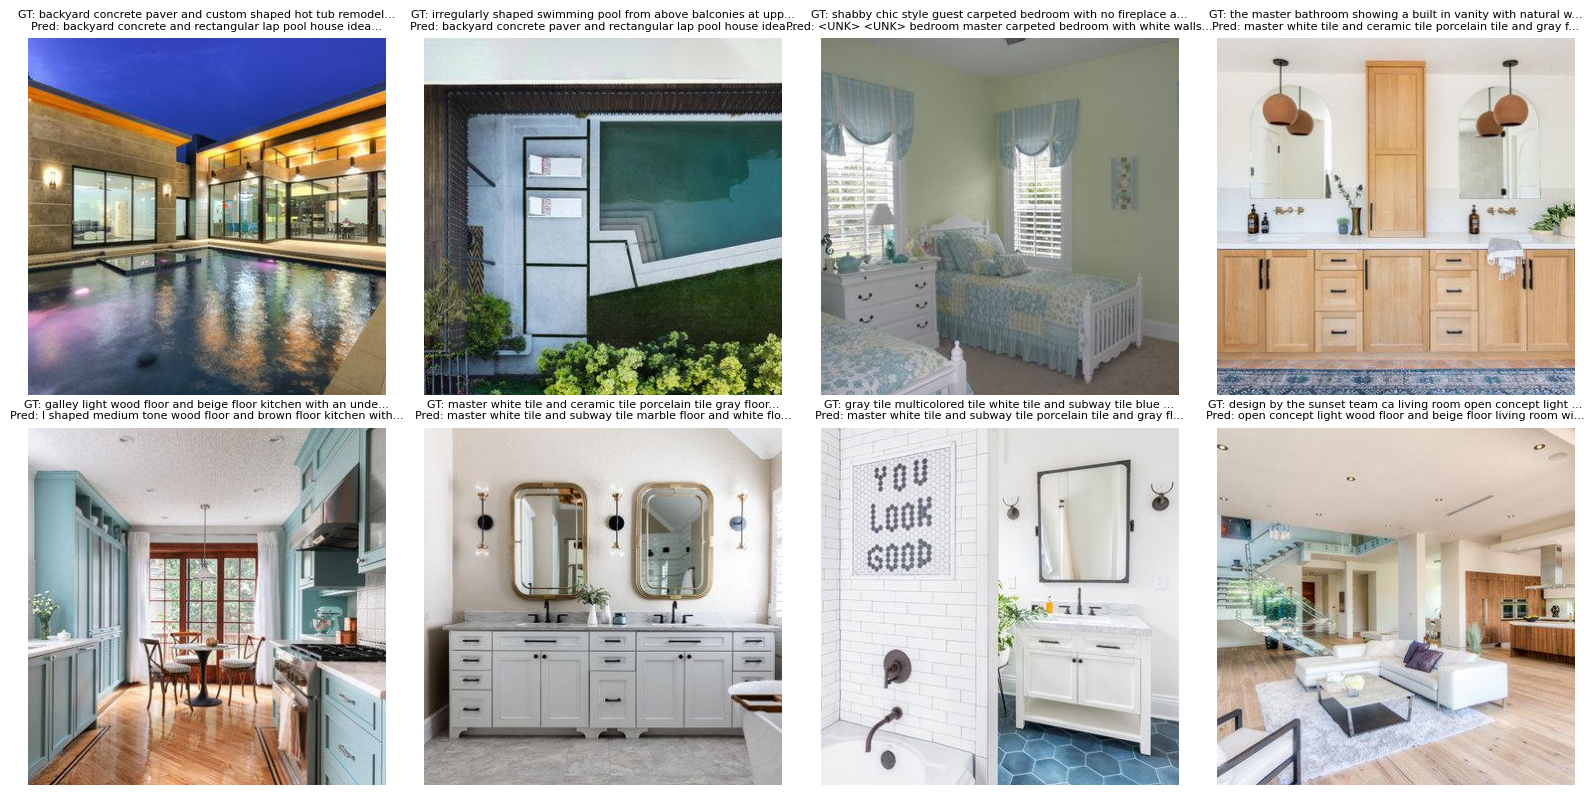

In [47]:
# ─── Load best checkpoint ────────────────────────────────────────────────────
ckpt = torch.load(SAVE_PATH / 'best_model.pth', map_location=DEVICE)

_encoder = encoder.module if USE_MULTI else encoder
_decoder = decoder.module if USE_MULTI else decoder
_encoder.load_state_dict(ckpt['encoder'])
_decoder.load_state_dict(ckpt['decoder'])
_encoder.eval(); _decoder.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']} (val_loss={ckpt['best_val_loss']:.4f})")


@torch.no_grad()
def generate_caption_greedy(image_tensor: torch.Tensor, max_len: int = MAX_SEQ_LEN) -> str:
    image_tensor = image_tensor.unsqueeze(0).to(DEVICE)
    feats = _encoder(image_tensor)                            # (1, 256)
    h     = _decoder.hidden_proj(feats)                       # (1, hidden)
    h     = h.unsqueeze(0).repeat(_decoder.num_layers, 1, 1)  # (layers, 1, hidden)

    token   = torch.tensor([[START_IDX]], device=DEVICE)
    output  = []
    for _ in range(max_len):
        emb        = _decoder.embed(token)
        out, h     = _decoder.gru(emb, h)
        logits     = _decoder.fc_out(out[:, -1, :])
        next_token = logits.argmax(-1).item()
        if next_token == END_IDX:
            break
        if next_token not in (PAD_IDX, START_IDX):
            output.append(next_token)
        token = torch.tensor([[next_token]], device=DEVICE)

    return ' '.join(idx2word[i] for i in output)


# ─── Sample a few test images ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_rows = test_df.sample(8, random_state=42).reset_index(drop=True)

for i, (ax, row) in enumerate(zip(axes.flat, sample_rows.itertuples())):
    img_name = '/'.join(row.local_path.split('/')[1:])
    img      = Image.open(IMAGES_BASE / img_name).convert('RGB')
    img_t    = val_transform(img)
    pred     = generate_caption_greedy(img_t)

    ax.imshow(img); ax.axis('off')
    ax.set_title(f'GT: {row.caption[:60]}...\nPred: {pred[:60]}...', fontsize=8)

plt.tight_layout()
plt.savefig(SAVE_PATH / 'sample_captions.png', dpi=120, bbox_inches='tight')
plt.show()


## 11. Full Evaluation: BLEU + METEOR + ROUGE-L + CIDEr

In [48]:
# ─── Generate all test captions ──────────────────────────────────────────────
predictions = []
print('Generating test captions ...')
for row in tqdm(test_df.itertuples(), total=len(test_df)):
    img_name = '/'.join(row.local_path.split('/')[1:])
    img      = Image.open(IMAGES_BASE / img_name).convert('RGB')
    img_t    = val_transform(img)
    pred     = generate_caption_greedy(img_t)
    predictions.append(pred)

test_df = test_df.copy()
test_df['generated'] = predictions
print('done')


Generating test captions ...


  0%|          | 0/1374 [00:00<?, ?it/s]

done


In [49]:
from nltk.translate.bleu_score  import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score                 import rouge_scorer
from collections                 import defaultdict
import math

# References / hypotheses
refs   = [[r.caption.split()] for r in test_df.itertuples()]
hyps   = [g.split() for g in test_df['generated']]

# BLEU-1 / BLEU-4
sm     = SmoothingFunction().method1
bleu1  = corpus_bleu(refs, hyps, weights=(1, 0, 0, 0),       smoothing_function=sm)
bleu4  = corpus_bleu(refs, hyps, weights=(0.25,)*4,          smoothing_function=sm)

# METEOR (per-sample then averaged)
meteor = float(np.mean([
    meteor_score([r[0]], h) for r, h in zip(refs, hyps)
]))

# ROUGE-L
rscorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
rouge_l = float(np.mean([
    rscorer.score(r.caption, g)['rougeL'].fmeasure
    for r, g in zip(test_df.itertuples(), test_df['generated'])
]))

# CIDEr (simple implementation; matches what the ResNet notebook reports)
def cider_score(refs_list, hyps_list, n=4, sigma=6.0):
    def ngrams(tokens, k):
        return [tuple(tokens[i:i+k]) for i in range(len(tokens)-k+1)]

    # Document frequency over references
    df = defaultdict(int)
    N  = len(refs_list)
    for ref_group in refs_list:
        seen = set()
        for ref in ref_group:
            for k in range(1, n+1):
                for ng in ngrams(ref, k):
                    if ng not in seen:
                        df[ng] += 1
                        seen.add(ng)

    def tfidf_vec(tokens, k):
        counts = defaultdict(int)
        for ng in ngrams(tokens, k):
            counts[ng] += 1
        vec  = {}
        norm = 0.0
        for ng, c in counts.items():
            idf      = math.log(max(1.0, N / max(1, df[ng])))
            v        = c * idf
            vec[ng]  = v
            norm    += v * v
        return vec, math.sqrt(norm)

    scores = []
    for hyp, ref_group in zip(hyps_list, refs_list):
        per_k = []
        for k in range(1, n+1):
            hv, hn = tfidf_vec(hyp, k)
            sims   = []
            for ref in ref_group:
                rv, rn = tfidf_vec(ref, k)
                if hn == 0 or rn == 0:
                    sims.append(0.0); continue
                dot = sum(hv.get(ng, 0.0) * rv.get(ng, 0.0) for ng in hv)
                # length penalty
                delta = len(hyp) - len(ref)
                pen   = math.exp(- (delta ** 2) / (2 * sigma ** 2))
                sims.append(pen * dot / (hn * rn))
            per_k.append(np.mean(sims) if sims else 0.0)
        scores.append(10.0 * np.mean(per_k))
    return float(np.mean(scores))


cider = cider_score(refs, hyps)

print(f'BLEU-1  : {bleu1:.4f}')
print(f'BLEU-4  : {bleu4:.4f}')
print(f'METEOR  : {meteor:.4f}')
print(f'ROUGE-L : {rouge_l:.4f}')
print(f'CIDEr   : {cider:.4f}')


BLEU-1  : 0.3711
BLEU-4  : 0.1761
METEOR  : 0.3744
ROUGE-L : 0.3793
CIDEr   : 0.9854


In [50]:
# ─── Room-type accuracy (same synonym map as ResNet eval) ────────────────────
room_keywords = {
    'bathroom'   : ['bathroom', 'bath', 'shower', 'tub', 'vanity', 'toilet', 'sink', 'faucet', 'tile'],
    'bedroom'    : ['bedroom', 'bed', 'mattress', 'pillow', 'nightstand', 'headboard', 'sleeping', 'duvet'],
    'home-office': ['office', 'desk', 'study', 'workspace', 'workstation', 'computer', 'bookshelf', 'shelving', 'chair'],
    'kitchen'    : ['kitchen', 'cabinet', 'counter', 'stove', 'oven', 'refrigerator', 'cooking', 'sink', 'island', 'appliance', 'backsplash'],
    'living-room': ['living', 'lounge', 'sofa', 'couch', 'fireplace', 'mantel', 'seating', 'coffee table', 'sectional'],
    'pool'       : ['pool', 'swim', 'patio', 'outdoor', 'deck', 'backyard', 'spa', 'hot tub', 'water', 'lounge'],
}


def room_match(generated: str, room_type: str) -> bool:
    g = generated.lower()
    return any(kw in g for kw in room_keywords.get(room_type, []))


test_df['room_correct'] = [
    room_match(g, rt) for g, rt in zip(test_df['generated'], test_df['room_type'])
]
room_acc = float(test_df['room_correct'].mean()) * 100.0
print(f'Room-type accuracy: {room_acc:.2f}%')

# ─── Save predictions + metrics ─────────────────────────────────────────────
out_pred = test_df[['local_path', 'room_type', 'caption', 'generated']].copy()
out_pred = out_pred.rename(columns={'caption': 'true_caption'})
out_pred.to_csv(SAVE_PATH / 'test_predictions.csv', index=False)

metrics = {
    'model'         : 'EfficientNet-B0 (features[-2:] fine-tuned) + GRU',
    'best_val_loss' : best_val_loss,
    'test_samples'  : len(test_df),
    'BLEU-1'        : bleu1,
    'BLEU-4'        : bleu4,
    'METEOR'        : meteor,
    'ROUGE-L'       : rouge_l,
    'CIDEr'         : cider,
    'Room_Acc_%'    : room_acc,
    'hyperparams'   : {
        'EMBED_DIM'   : EMBED_DIM,
        'HIDDEN_DIM'  : HIDDEN_DIM,
        'BATCH_SIZE'  : BATCH_SIZE,
        'LR'          : LR,
        'NUM_EPOCHS'  : NUM_EPOCHS,
        'DROPOUT'     : DROPOUT,
        'LABEL_SMOOTH': LABEL_SMOOTH,
        'GRAD_CLIP'   : GRAD_CLIP,
        'FINE_TUNE'   : FINE_TUNE,
    },
}

with open(SAVE_PATH / 'eval_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Saved eval_metrics.json and test_predictions.csv')


Room-type accuracy: 87.19%
Saved eval_metrics.json and test_predictions.csv


## 12. Export Encoder for the LSTM Decoder

In [54]:
# ─── Export encoder only (drop-in for DecoderLSTM/) ──────────────────────────
_enc_to_save = encoder.module if USE_MULTI else encoder

torch.save({
    'encoder_state_dict' : _enc_to_save.state_dict(),

    # Architecture
    'backbone'           : 'efficientnet_b0',
    'embed_dim'          : EMBED_DIM,
    'fine_tune'          : FINE_TUNE,
    'dropout'            : DROPOUT,

    # Vocab
    'vocab_size'         : VOCAB_SIZE,
    'pad_idx'            : PAD_IDX,
    'start_idx'          : START_IDX,
    'end_idx'            : END_IDX,
    'word2idx'           : word2idx,
    'idx2word'           : idx2word,

    # Training context
    'best_val_loss'      : best_val_loss,
    'img_mean'           : IMG_MEAN,
    'img_std'            : IMG_STD,
    'max_seq_len'        : MAX_SEQ_LEN,
}, SAVE_PATH / 'encoder_for_decoder.pth')

print('Encoder exported -> encoder_for_lstm.pth')
print('Keys match the ResNet export schema, so DecoderGRU/ loads it unchanged')
print('(except the LSTM decoder must rebuild EncoderEfficientNetB0, not EncoderResNet50).')


Encoder exported -> encoder_for_lstm.pth
Keys match the ResNet export schema, so DecoderLSTM/ loads it unchanged
(except the LSTM decoder must rebuild EncoderEfficientNetB0, not EncoderResNet50).


## 13. Verify Export (Optional)

In [55]:
# ─── Reload encoder from scratch and confirm it works ────────────────────────
verify_ckpt = torch.load( SAVE_PATH / 'encoder_for_decoder.pth', map_location=DEVICE)

verify_enc = EncoderEfficientNetB0(
    embed_dim=verify_ckpt['embed_dim'],
    fine_tune=False,
    dropout=0.0,
).to(DEVICE)
verify_enc.load_state_dict(verify_ckpt['encoder_state_dict'])
verify_enc.eval()

with torch.no_grad():
    imgs, _ = next(iter(test_loader))
    imgs    = imgs.to(DEVICE)
    feats   = verify_enc(imgs)

print(f'Reloaded encoder output: {feats.shape}  (expected [B, {EMBED_DIM}])')
assert feats.shape[-1] == EMBED_DIM
print('Verification passed — checkpoint is consumable by the GRU decoder.')


Reloaded encoder output: torch.Size([64, 256])  (expected [B, 256])
Verification passed — checkpoint is consumable by the LSTM decoder.


---